# Dimensionality Reduction — Curse of Dimensionality & PCA

Two parts:

**Part A — Curse of Dimensionality**: a small experiment showing *why* high-dimensional data
is a problem for distance-based algorithms.
**Part B — PCA**: reducing a 5-feature dataset down to 2 principal components while keeping
the structure (clusters) intact.


## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
RANDOM_STATE = 42

## Part A — Curse of Dimensionality

As the number of features (dimensions) grows, distances between points start to look
**almost identical** — everything ends up "equally far" from everything else. This is bad news
for any algorithm that relies on distance (KNN, K-Means, DBSCAN...).

We demonstrate this by generating random points in increasing numbers of dimensions and
measuring the **relative spread of pairwise distances** (`std / mean`). As dimensions increase,
this ratio should shrink toward zero — distances stop being informative.


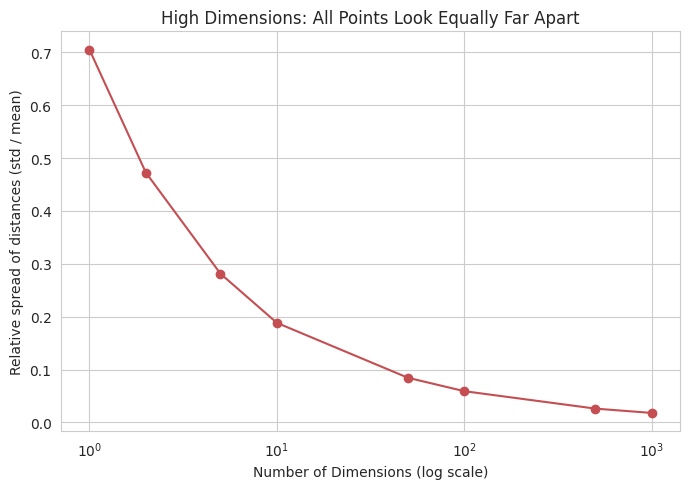

In [2]:
from scipy.spatial.distance import pdist

rng = np.random.RandomState(RANDOM_STATE)
dims_to_test = [1, 2, 5, 10, 50, 100, 500, 1000]
spread_ratios = []

for d in dims_to_test:
    points = rng.rand(200, d)                 # 200 random points in d dimensions
    dists = pdist(points)                      # all pairwise distances
    spread_ratios.append(dists.std() / dists.mean())

plt.figure(figsize=(7, 5))
plt.plot(dims_to_test, spread_ratios, marker='o', color='#C44E52')
plt.xscale('log')
plt.xlabel('Number of Dimensions (log scale)')
plt.ylabel('Relative spread of distances (std / mean)')
plt.title('High Dimensions: All Points Look Equally Far Apart')
plt.tight_layout()
plt.show()

This is exactly the motivation for **dimensionality reduction**: either drop features
(**feature selection**) or combine them into fewer, information-dense new features
(**feature extraction** — what PCA does).


## Part B — PCA (Principal Component Analysis)

### B.1 Generate a 5-Dimensional Dataset

Three well-separated clusters, but spread across **5 features** instead of the usual 2 —
so we can't just plot it directly.


In [3]:
X, y = make_blobs(n_samples=500, n_features=5, centers=3, cluster_std=1.5, random_state=RANDOM_STATE)
print(f"Shape: {X.shape}  (500 samples, 5 features)")

Shape: (500, 5)  (500 samples, 5 features)


### B.2 Scale the Features

PCA is variance-based, so features need to be on the same scale first.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### B.3 Fit PCA & Inspect Explained Variance

Each principal component captures a decreasing share of the total variance. We check how much
of the original 5-feature information the first 2 components alone preserve.


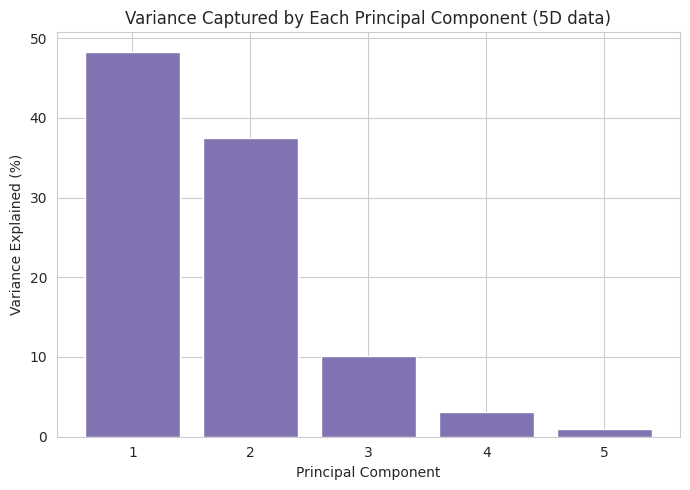

PC1 + PC2 explain 85.8% of the total variance


In [5]:
pca_full = PCA(n_components=5)
pca_full.fit(X_scaled)

variance_pct = pca_full.explained_variance_ratio_ * 100

plt.figure(figsize=(7, 5))
plt.bar(range(1, 6), variance_pct, color='#8172B2')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('Variance Captured by Each Principal Component (5D data)')
plt.tight_layout()
plt.show()

print(f"PC1 + PC2 explain {variance_pct[:2].sum():.1f}% of the total variance")

### B.4 Reduce to 2 Dimensions & Visualize

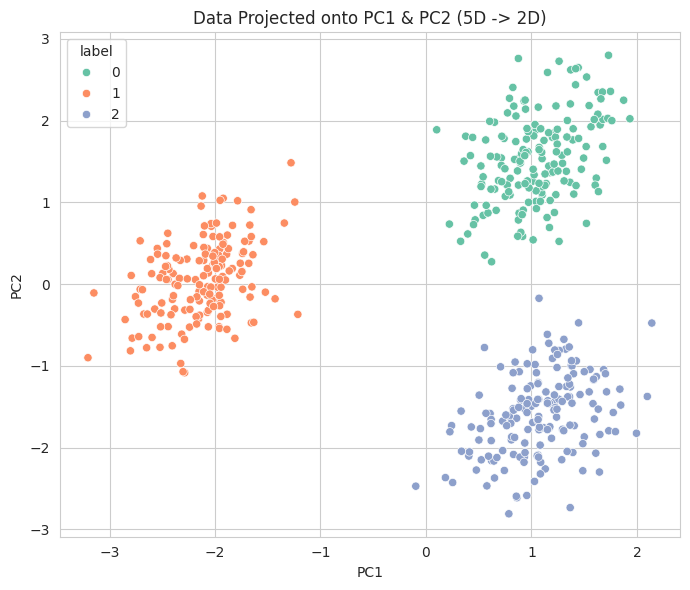

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['label'] = y

plt.figure(figsize=(7, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='label', palette='Set2')
plt.title('Data Projected onto PC1 & PC2 (5D -> 2D)')
plt.tight_layout()
plt.show()

## Takeaways

- **Curse of dimensionality**: too many features makes distances uninformative and blows up
  storage/training cost — distance-based algorithms suffer the most.
- **Feature selection** keeps a subset of the original features; **feature extraction** (PCA)
  combines them into new ones that capture maximum variance.
- **PCA** let us go from 5 features down to 2 while keeping the 3 original clusters clearly
  separable — most of the "information" lived in just the first 2 components.
